In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

In [16]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [17]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
print(x_train.shape)
print(x_test.shape)
x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [18]:
print(y_train.shape)
print(y_test.shape)

(60000,)
(10000,)


In [19]:
print(y_train[0])

5


In [20]:
model = keras.Sequential([
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(64, (3, 3), activation="relu"),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(128, activation="relu"),
layers.Dense(10, activation="softmax") # 10 classes for MNIST digits
])

In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(optimizer="adam",

loss="sparse_categorical_crossentropy", # labels are in integer
metrics=["accuracy"])

In [23]:
model.fit(x_train, y_train, epochs=1, batch_size=32, validation_data=(x_test, y_test))

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 29ms/step - accuracy: 0.9621 - loss: 0.1236 - val_accuracy: 0.9849 - val_loss: 0.0451


In [24]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9849 - loss: 0.0451
Test accuracy: 0.9849


In [25]:
predictions = model.predict(x_test[:5])
print(predictions.shape)
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
(5, 10)
Predicted labels: [7 2 1 0 4]
Actual labels:  [7 2 1 0 4]


##7 Exercise.
Implement an End to End CNN Model for Image Classification Task.

##Task 1: Data Understanding and Visualization:
Download the Provided Data and Complete the following task.

1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class. You are expected to write a code:

• Get the list of class directories from the train folder.
• Select one image randomly from each class.
• Display the images in a grid format with two rows using matplotlib.
• Expected Output:

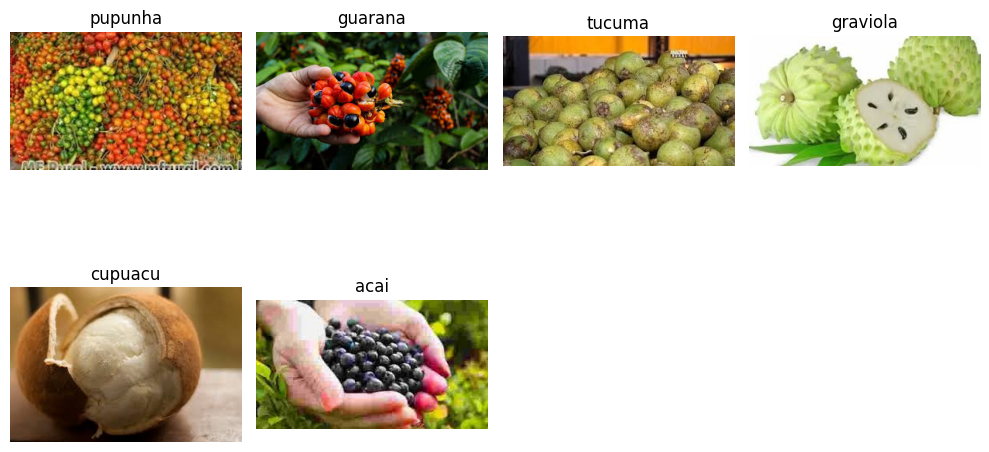

In [26]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/drive/MyDrive/AI and Machine Learning/FruitinAmazon/FruitinAmazon/train"

classes = os.listdir(train_dir)

images = []
labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)
    images.append(img)
    labels.append(cls)

# Display images (2 rows grid)
plt.figure(figsize=(10, 6))

for i in range(len(images)):
    plt.subplot(2, len(images)//2 + 1, i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##• What did you Observe?

Each folder represents a fruit class

Images vary in size, lighting, and angle

Some classes may have more samples than others

##2. Check for Corrupted Image: Write a script that verifies whether the image in the train
directory are valid. If any corrupted images are found, the script must remove the image from
the directory and print the message which image have been removed, if none found print ”No
Corrupted Images Found.”
• Hint:
– Iterate through each class subdirectory and check if each image is valid.
– Use the Image.open() function to attempt to load each image.
– If the image is corrupted i.e. raises an IOError or SyntaxError, remove the image from
the directory and print f"Removed corrupted image: {image_path}".
– Maintain a list of all corrupted image paths for reporting.

In [28]:
from PIL import Image
import os

corrupted = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


##Task 2: Loading and Preprocessing Image Data in keras:

In [29]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Store class_names before applying transformations
class_names = train_ds.class_names

# Normalize
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


##Data activation:

In [30]:
num_classes = len(class_names)

model = keras.Sequential([
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

##Task 3 - Implement a CNN with

##Convolutional Architecture:
• Convolutional Layer 1:
– Filter Size (F): (3, 3)
– Number of Filters (k): 32
– Padding (P): same
– Stride (s): 1

• Activation Layer: ReLU activation

• Pooling Layer 1: Max pooling
– Filter Size (F): (2, 2)
– Stride (s): 2

• Convolutional Layer 2:
– Filter Size (F): (3, 3)
– Number of Filters (k): 32
– Padding (P): same
– Stride (s): 1

• Activation Layer: ReLU activation

• Pooling Layer 2: Max pooling
– Filter Size (F): (2, 2)
– Stride (s):2

Fully Connected Network Architecture:
• Flatten Layer: Flatten the input coming from the convolutional layers

• Input Layer:

• Hidden Layer - 2:

– Number of Neurons: 64,
– Number of Neurons: 128

In [31]:
from tensorflow.keras import layers, models

num_classes = len(classes)

model = models.Sequential([
    # Conv Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Block 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Fully Connected
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

##Task 4: Compile the Model

In [32]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

##Task 4: Train the Model
Model Training
• Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.

• Use val ds for validation.

• Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoid-
ing overfitting.

In [33]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)
earlystop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.2263 - loss: 1.9720

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 688ms/step - accuracy: 0.1944 - loss: 2.0446 - val_accuracy: 0.0000e+00 - val_loss: 1.8636
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 411ms/step - accuracy: 0.2361 - loss: 1.7850 - val_accuracy: 0.0000e+00 - val_loss: 1.9235
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.2234 - loss: 1.7090

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 829ms/step - accuracy: 0.2639 - loss: 1.6790 - val_accuracy: 0.0000e+00 - val_loss: 1.7309
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.2188 - loss: 1.6369

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 766ms/step - accuracy: 0.2500 - loss: 1.6200 - val_accuracy: 0.3889 - val_loss: 1.6149
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.4751 - loss: 1.4384

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 467ms/step - accuracy: 0.4722 - loss: 1.4567 - val_accuracy: 0.4444 - val_loss: 1.4829
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.6765 - loss: 1.2693

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 785ms/step - accuracy: 0.9444 - loss: 0.0989 - val_accuracy: 0.8333 - val_loss: 0.4003
Epoch 26/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 1.0000 - loss: 0.0400

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 473ms/step - accuracy: 1.0000 - loss: 0.0381 - val_accuracy: 0.8333 - val_loss: 0.3612
Epoch 27/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 522ms/step - accuracy: 0.9861 - loss: 0.0554 - val_accuracy: 0.8333 - val_loss: 0.5116
Epoch 28/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 434ms/step - accuracy: 0.9722 - loss: 0.0783 - val_accuracy: 0.8333 - val_loss: 0.5282
Epoch 29/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 501ms/step - accuracy: 1.0000 - loss: 0.0597 - val_accuracy: 0.8333 - val_loss: 0.5938
Epoch 30/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 438ms/step - accuracy: 0.9722 - loss: 0.0585 - val_accuracy: 0.8333 - val_loss: 0.5374
Epoch 31/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.9902 - loss: 0.0610

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 845ms/step - accuracy: 0.9861 - loss: 0.0633 - val_accuracy: 0.8889 - val_loss: 0.2646
Epoch 32/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.9751 - loss: 0.0632

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 780ms/step - accuracy: 0.9722 - loss: 0.0667 - val_accuracy: 0.8889 - val_loss: 0.2114
Epoch 33/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 434ms/step - accuracy: 0.9861 - loss: 0.0320 - val_accuracy: 0.8889 - val_loss: 0.2658
Epoch 34/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 448ms/step - accuracy: 1.0000 - loss: 0.0415 - val_accuracy: 0.8333 - val_loss: 0.4408
Epoch 35/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 424ms/step - accuracy: 0.9583 - loss: 0.0820 - val_accuracy: 0.8333 - val_loss: 0.7193
Epoch 36/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 433ms/step - accuracy: 0.9722 - loss: 0.0542 - val_accuracy: 0.8333 - val_loss: 1.0259
Epoch 37/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 439ms/step - accuracy: 0.9722 - loss: 0.0705 - val_accuracy: 0.8333 - val_loss: 0.8603
Epoch 38/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 481ms/step - accuracy: 0.9861 - loss: 0.0392 - val_accuracy: 0.8333 - val_loss: 0.5147
Epoch 39/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 767ms/step - accuracy: 0.9861 - loss: 0.0346 - val_accuracy: 0.8889 - val_lo

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 685ms/step - accuracy: 1.0000 - loss: 0.0262 - val_accuracy: 0.9444 - val_loss: 0.1268
Epoch 41/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 432ms/step - accuracy: 0.9861 - loss: 0.0419 - val_accuracy: 0.8333 - val_loss: 0.2169
Epoch 42/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 459ms/step - accuracy: 1.0000 - loss: 0.0130 - val_accuracy: 0.8333 - val_loss: 0.4921
Epoch 43/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 427ms/step - accuracy: 0.9861 - loss: 0.0394 - val_accuracy: 0.8333 - val_loss: 0.6516
Epoch 44/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 449ms/step - accuracy: 1.0000 - loss: 0.0275 - val_accuracy: 0.8333 - val_loss: 0.6905
Epoch 45/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 436ms/step - accuracy: 1.0000 - loss: 0.0128 - val_accuracy: 0.8333 - val_loss: 0.6066
Epoch 46/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 626ms/step - accuracy: 0.9861 - loss: 0.0253 - val_accuracy: 0.8333 - val_loss: 0.3979
Epoch 47/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 868ms/step - accuracy: 0.9861 - loss: 0.0219 - val_accuracy: 0.8333 - val_lo

##Task 5: Evaluate the Model
Model Evaluation
• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [34]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.9444 - loss: 0.1268
Validation Accuracy: 0.9444444179534912


##Task 6: Save and Load the Model
Model Saving and Loading

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [35]:
model.save("fruit_model.h5")

from tensorflow.keras.models import load_model
loaded_model = load_model("fruit_model.h5")

loaded_model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.9444 - loss: 0.1268


[0.1267978549003601, 0.9444444179534912]

##Task 7: Predictions and Classification Report
Making Predictions

• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().

• Also use from sklearn.metrics import classification report to report the Classification
Report of your Model Performance.

In [36]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

# Get unique labels from both true and predicted values
unique_labels = np.unique(np.concatenate((y_true, y_pred)))

# Create target names corresponding to the unique labels
# The `classes` variable already stores the class names in order of their integer labels.
# So, we can just pick the names using the unique_labels as indices.
display_target_names = [classes[i] for i in unique_labels if i < len(classes)]

# Ensure that the labels and target_names are aligned
print(classification_report(y_true, y_pred, labels=unique_labels, target_names=display_target_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
              precision    recall  f1-score   support

     cupuacu       0.75      1.00      0.86         3
        acai       1.00      0.93      0.97        15

    accuracy                           0.94        18
   macro avg       0.88      0.97      0.91        18
weighted avg       0.96      0.94      0.95        18



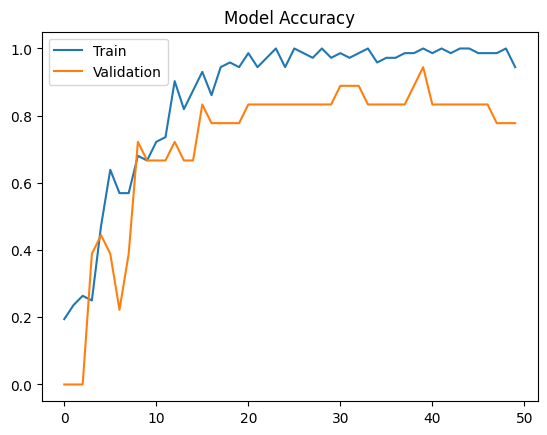

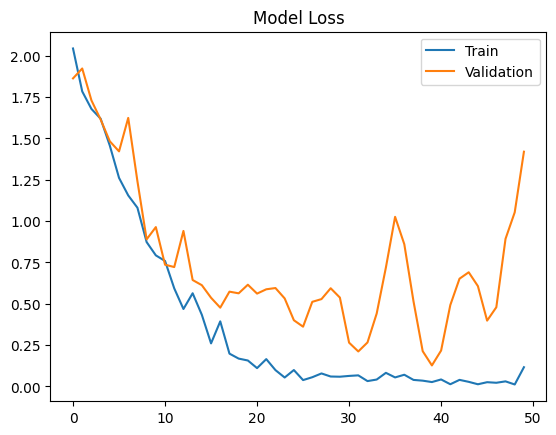

In [37]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(['Train', 'Validation'])
plt.show()